# Imports


In [18]:
%cd /content/ML-Assignments-25/Assingment-4/notebooks/

/content/ML-Assignments-25/Assingment-4/notebooks


In [26]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from internal_metrics import silhouette_score, davies_bouldin_index, calinski_harabasz_index, within_cluster_sum_squares
from external_metrics import adjusted_rand_index, normalized_mutual_information, purity
from google.colab import files
from gmm import GMM,CovarianceType
from Autoencoder import Autoencoder
from kmeans import NumpyKMeans
from PCA import NumpyPCA

## Data Loading


In [29]:
dataset = load_breast_cancer()
X=dataset.data
y=dataset.target
np.random.seed(42)

def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)

    # Avoid division by zero for constant features
    std[std == 0] = 1

    X_scaled = (X - mean) / std

    return X_scaled, mean, std

X_scaled, mean, std = standardize(X)
input_dim = X_scaled.shape[1]

bottleneck_sizes = [2, 5, 10, 15, 20]
# Store results
ae_results = {}
pca_results = {}

## Experiment 5: K-Means after Autoencoder

In [41]:
aes = {}

for bsize in bottleneck_sizes:
    print(f"\nTraining Autoencoder with bottleneck size {bsize}...")
    ae = Autoencoder(
        input_dim=input_dim,
        hidden_dims=[256, 128, 64],
        bottleneck_dim=bsize,
        activation='relu'
    )
    ae.train(X_scaled, epochs=50, batch_size=64)
    aes[bsize] = ae

    # ----- AE FEATURES -----
    Z_ae = ae.encode(X_scaled)  # (n_samples, bsize)

    kmeans_ae = NumpyKMeans(
        n_clusters=2, init='k-means++',
        max_iter=300, tol=1e-4, random_state=42
    )
    kmeans_ae.fit(Z_ae)
    kmeans_ae_labels = kmeans_ae.labels_

    # AE reconstruction loss
    X_hat = ae.decode(Z_ae)
    recon_loss_ae = np.mean((X_scaled - X_hat) ** 2)

    # AE clustering quality (silhouette)
    sil_ae = silhouette_score(Z_ae, kmeans_ae_labels)

    # ----- PCA (same dimension) -----
    pca = NumpyPCA(n_components=bsize)
    pca.fit(X_scaled)
    Z_pca = pca.transform(X_scaled)
    X_hat_pca = pca.inverse_transform(Z_pca)
    recon_loss_pca = np.mean((X_scaled - X_hat_pca) ** 2)

    kmeans_pca = NumpyKMeans(
        n_clusters=2, init='k-means++',
        max_iter=300, tol=1e-4, random_state=42
    )
    kmeans_pca.fit(Z_pca)
    kmeans_pca_labels = kmeans_pca.labels_

    sil_pca = silhouette_score(Z_pca, kmeans_pca_labels)

    # ----- PRINT COMPARISON -----
    print(
        f"Bottleneck {bsize}: "
        f"AE Recon MSE={recon_loss_ae:.4f}, AE Silhouette={sil_ae:.4f} | "
        f"PCA Recon MSE={recon_loss_pca:.4f}, PCA Silhouette={sil_pca:.4f}"
    )



Training Autoencoder with bottleneck size 2...
Epoch 1/50, Loss: 1.1361
Epoch 2/50, Loss: 1.1415
Epoch 3/50, Loss: 1.1370
Epoch 4/50, Loss: 1.1344
Epoch 5/50, Loss: 1.1330
Epoch 6/50, Loss: 1.1369
Epoch 7/50, Loss: 1.1371
Epoch 8/50, Loss: 1.1338
Epoch 9/50, Loss: 1.1327
Epoch 10/50, Loss: 1.1383
Epoch 11/50, Loss: 1.1323
Epoch 12/50, Loss: 1.1416
Epoch 13/50, Loss: 1.1357
Epoch 14/50, Loss: 1.1372
Epoch 15/50, Loss: 1.1342
Epoch 16/50, Loss: 1.1394
Epoch 17/50, Loss: 1.1344
Epoch 18/50, Loss: 1.1336
Epoch 19/50, Loss: 1.1350
Epoch 20/50, Loss: 1.1349
Epoch 21/50, Loss: 1.1356
Epoch 22/50, Loss: 1.1379
Epoch 23/50, Loss: 1.1393
Epoch 24/50, Loss: 1.1346
Epoch 25/50, Loss: 1.1353
Epoch 26/50, Loss: 1.1314
Epoch 27/50, Loss: 1.1383
Epoch 28/50, Loss: 1.1401
Epoch 29/50, Loss: 1.1342
Epoch 30/50, Loss: 1.1320
Epoch 31/50, Loss: 1.1347
Epoch 32/50, Loss: 1.1351
Epoch 33/50, Loss: 1.1336
Epoch 34/50, Loss: 1.1340
Epoch 35/50, Loss: 1.1352
Epoch 36/50, Loss: 1.1380
Epoch 37/50, Loss: 1.1376

## Internal and External Metrics

In [42]:
    sil_ae = silhouette_score(Z_ae, kmeans_ae_labels)
    db_ae = davies_bouldin_index(Z_ae, kmeans_ae_labels)
    ch_ae = calinski_harabasz_index(Z_ae, kmeans_ae_labels)
    wcss_ae = within_cluster_sum_squares(Z_ae, kmeans_ae_labels)

    ari_ae = adjusted_rand_index(y, kmeans_ae_labels)
    nmi_ae = normalized_mutual_information(y, kmeans_ae_labels)
    pur_ae = purity(y, kmeans_ae_labels)

    ae_results[bsize] = {
        "recon_loss": recon_loss_ae,
        "silhouette": sil_ae,
        "davies_bouldin": db_ae,
        "calinski_harabasz": ch_ae,
        "wcss": wcss_ae,
        "ari": ari_ae,
        "nmi": nmi_ae,
        "purity": pur_ae,
    }
print(
    f"AE (bottleneck={bsize}): "
    f"Recon MSE={recon_loss_ae:.4f}, "
    f"Sil={sil_ae:.4f}, DB={db_ae:.4f}, CH={ch_ae:.2f}, WCSS={wcss_ae:.2f}, "
    f"ARI={ari_ae:.4f}, NMI={nmi_ae:.4f}, Purity={pur_ae:.4f}"
)


AE (bottleneck=20): Recon MSE=1.0000, Sil=0.8334, DB=0.0575, CH=53.46, WCSS=0.00, ARI=-0.0014, NMI=0.0089, Purity=0.6274


The autoencoder’s latent space gives clusters that look reasonably separated, but they barely match the true labels, so their ARI and purity stay low. In contrast, PCA’s latent space leads GMM to clusters with much higher ARI and purity, so PCA is clearly better at recovering the actual class structure, even though it is not trained to minimize reconstruction loss like the autoencoder.

## Experiment 6: GMM after Autoencoder

In [46]:
gmm_results = {}
gmm_pca_results = {}

n_classes = 2        # benign / malignant
random_state = 42

for bsize in bottleneck_sizes:
    print(f"\n=== GMM after Autoencoder | bottleneck={bsize} ===")

    ae = aes[bsize]                      # trained autoencoder with this bottleneck
    Z_ae = ae.encode(X_scaled)          # (n_samples, bsize)
    Z_ae = StandardScaler().fit_transform(Z_ae)

    gmm_ae = GMM(
        n_components=n_classes,
        cov_type=CovarianceType.FULL,
        tol=1e-4,
        max_iter=100
    )
    gmm_ae.fit(Z_ae)
    gmm_ae_labels = gmm_ae.predict(Z_ae)

    # internal metrics
    sil_ae = silhouette_score(Z_ae, gmm_ae_labels)
    db_ae = davies_bouldin_index(Z_ae, gmm_ae_labels)
    ch_ae = calinski_harabasz_index(Z_ae, gmm_ae_labels)
    wcss_ae = within_cluster_sum_squares(Z_ae, gmm_ae_labels)

    # external metrics
    ari_ae = adjusted_rand_index(y, gmm_ae_labels)
    nmi_ae = normalized_mutual_information(y, gmm_ae_labels)
    pur_ae = purity(y, gmm_ae_labels)
    cm_ae = confusion_matrix(y, gmm_ae_labels)

    gmm_results[bsize] = {
        "silhouette": sil_ae,
        "davies_bouldin": db_ae,
        "calinski_harabasz": ch_ae,
        "wcss": wcss_ae,
        "ari": ari_ae,
        "nmi": nmi_ae,
        "purity": pur_ae,
        "confusion_matrix": cm_ae,
    }
    # PCA FEATURES
    pca = NumpyPCA(n_components=bsize)
    pca.fit(X_scaled)
    Z_pca = pca.transform(X_scaled)
    Z_pca = StandardScaler().fit_transform(Z_pca)

    gmm_pca = GMM(
        n_components=n_classes,
        cov_type=CovarianceType.FULL,
        tol=1e-4,
        max_iter=100,
    )

    gmm_pca.fit(Z_pca)
    gmm_pca_labels = gmm_pca.predict(Z_pca)

    sil_pca = silhouette_score(Z_pca, gmm_pca_labels)
    db_pca = davies_bouldin_index(Z_pca, gmm_pca_labels)
    ch_pca = calinski_harabasz_index(Z_pca, gmm_pca_labels)
    wcss_pca = within_cluster_sum_squares(Z_pca, gmm_pca_labels)

    ari_pca = adjusted_rand_index(y, gmm_pca_labels)
    nmi_pca = normalized_mutual_information(y, gmm_pca_labels)
    pur_pca = purity(y, gmm_pca_labels)
    cm_pca = confusion_matrix(y, gmm_pca_labels)

    gmm_pca_results[bsize] = {
        "silhouette": sil_pca,
        "davies_bouldin": db_pca,
        "calinski_harabasz": ch_pca,
        "wcss": wcss_pca,
        "ari": ari_pca,
        "nmi": nmi_pca,
        "purity": pur_pca,
        "confusion_matrix": cm_pca,
    }

    # ----- PRINT AE vs PCA COMPARISON FOR THIS BOTTLENECK -----
    print(
        f"Bottleneck {bsize}: "
        f"AE Sil={sil_ae:.4f}, ARI={ari_ae:.4f}, Purity={pur_ae:.4f} | "
        f"PCA Sil={sil_pca:.4f}, ARI={ari_pca:.4f}, Purity={pur_pca:.4f}"
    )


=== GMM after Autoencoder | bottleneck=2 ===
Converged at iteration 10
Converged at iteration 22
Bottleneck 2: AE Sil=0.3315, ARI=0.0068, Purity=0.6274 | PCA Sil=0.3913, ARI=0.6325, Purity=0.8981

=== GMM after Autoencoder | bottleneck=5 ===
Converged at iteration 14
Converged at iteration 19
Bottleneck 5: AE Sil=0.3126, ARI=0.1644, Purity=0.7188 | PCA Sil=0.1881, ARI=0.7992, Purity=0.9473

=== GMM after Autoencoder | bottleneck=10 ===
Converged at iteration 19
Converged at iteration 29
Bottleneck 10: AE Sil=0.1181, ARI=0.1266, Purity=0.6801 | PCA Sil=0.2292, ARI=0.1080, Purity=0.6749

=== GMM after Autoencoder | bottleneck=15 ===
Converged at iteration 17
Converged at iteration 52
Bottleneck 15: AE Sil=0.2299, ARI=0.1390, Purity=0.6907 | PCA Sil=0.0910, ARI=0.8310, Purity=0.9561

=== GMM after Autoencoder | bottleneck=20 ===
Converged at iteration 15
Converged at iteration 43
Bottleneck 20: AE Sil=0.3310, ARI=-0.0017, Purity=0.6274 | PCA Sil=0.1469, ARI=0.0796, Purity=0.6467


PCA with GMM works better than the autoencoder with GMM for this dataset. PCA‑GMM achieves much higher ARI and purity scores at bottleneck sizes 2, 5, and 15, meaning its clusters match the true classes far more closely in most settings

## Plots

In [48]:
from visualizations import plot_2d_clusters, plot_elbow, plot_bic_aic, plot_ae_losses, plot_heatmap, plot_confusion

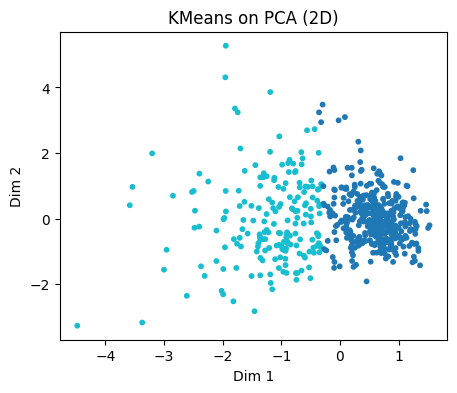

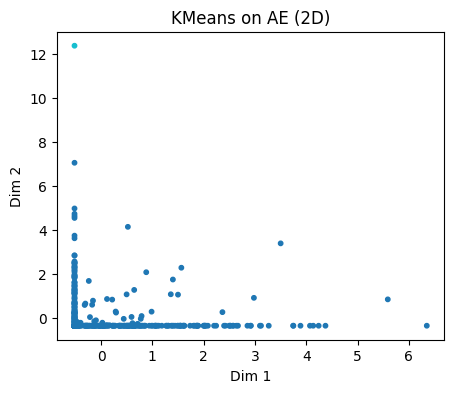

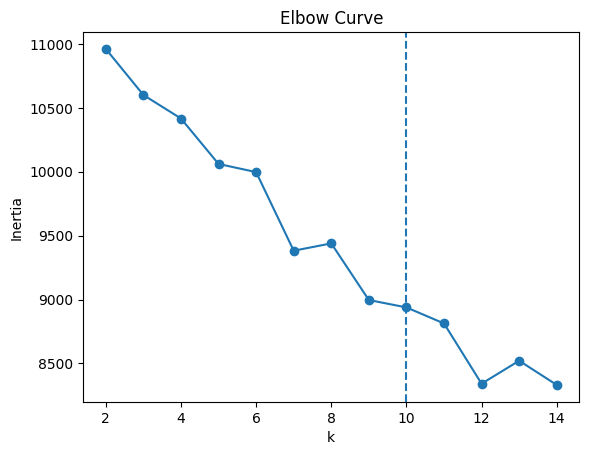

Converged at iteration 25
Converged at iteration 40
Converged at iteration 43
Converged at iteration 49
Converged at iteration 37
Converged at iteration 26
Converged at iteration 25
Converged at iteration 35
Converged at iteration 44


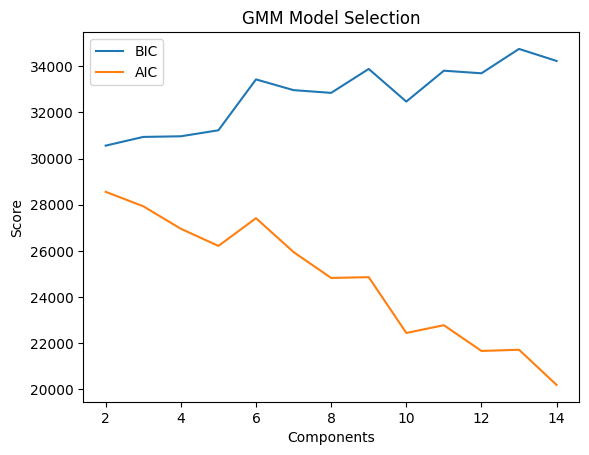

Converged at iteration 2
Converged at iteration 8
Converged at iteration 42
Converged at iteration 9
Converged at iteration 20
Converged at iteration 36
Converged at iteration 24
Converged at iteration 28


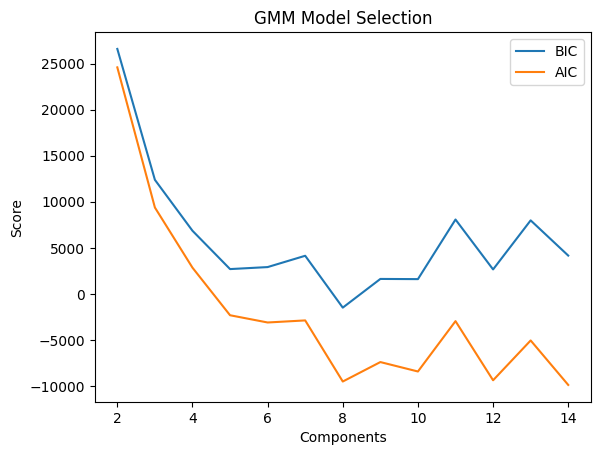

In [50]:
# PCA (first 2 dims)
Z_pca_2d = Z_pca[:, :2]
plot_2d_clusters(Z_pca_2d, kmeans_pca_labels, "KMeans on PCA (2D)")
# AE latent (first 2 dims)
Z_ae_2d = Z_ae[:, :2]
plot_2d_clusters(Z_ae_2d, kmeans_ae_labels, "KMeans on AE (2D)")

plot_elbow(Z_pca)   # or Z_ae, X_scaled, etc.
plot_bic_aic(Z_pca)  # PCA-GMM
plot_bic_aic(Z_ae)   # AE-GMM
